In [ ]:
import pandas as pd


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
df = pd.read_csv('data.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:\n", df.describe())
print("\nDuplicates:", df.duplicated().sum())
print("\nFirst few rows:")
df.head()

Shape: (541909, 8)

Dtypes:
 InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Basic stats:
             Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000

Duplicates: 5268

First few rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
# ---- STEP 2: Data Cleaning ----

# Drop rows where CustomerID is missing (can't segment without knowing the customer)
df = df.dropna(subset=['CustomerID'])

# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove cancelled orders (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove rows with zero or negative Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Remove duplicates
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)
print("Missing values:\n", df.isnull().sum())

Shape after cleaning: (392692, 8)
Missing values:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:
# ---- STEP 3: Feature Engineering ----

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(df[['Quantity', 'UnitPrice', 'TotalPrice']].head(10))

   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34
5         2       7.65       15.30
6         6       4.25       25.50
7         6       1.85       11.10
8         6       1.85       11.10
9        32       1.69       54.08


In [ ]:
# ---- STEP 4: Quick Sanity Checks ----

print("Unique customers:", df['CustomerID'].nunique())
print("Unique countries:", df['Country'].nunique())
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
print("\nTop 10 countries by transactions:")
print(df['Country'].value_counts().head(10))
print("\nTotalPrice stats:")
print(df['TotalPrice'].describe())

Unique customers: 4338
Unique countries: 37
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00

Top 10 countries by transactions:
Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64

TotalPrice stats:
count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64


In [ ]:
# ---- STEP 1: Descriptive Statistics at Customer Level ----
import matplotlib.pyplot as plt
import seaborn as sns

# Set a reference date (one day after the last transaction)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Build RFM table per customer
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("RFM Table Shape:", rfm.shape)
print("\nRFM Summary Statistics:")
rfm.describe()

RFM Table Shape: (4338, 4)

RFM Summary Statistics:


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


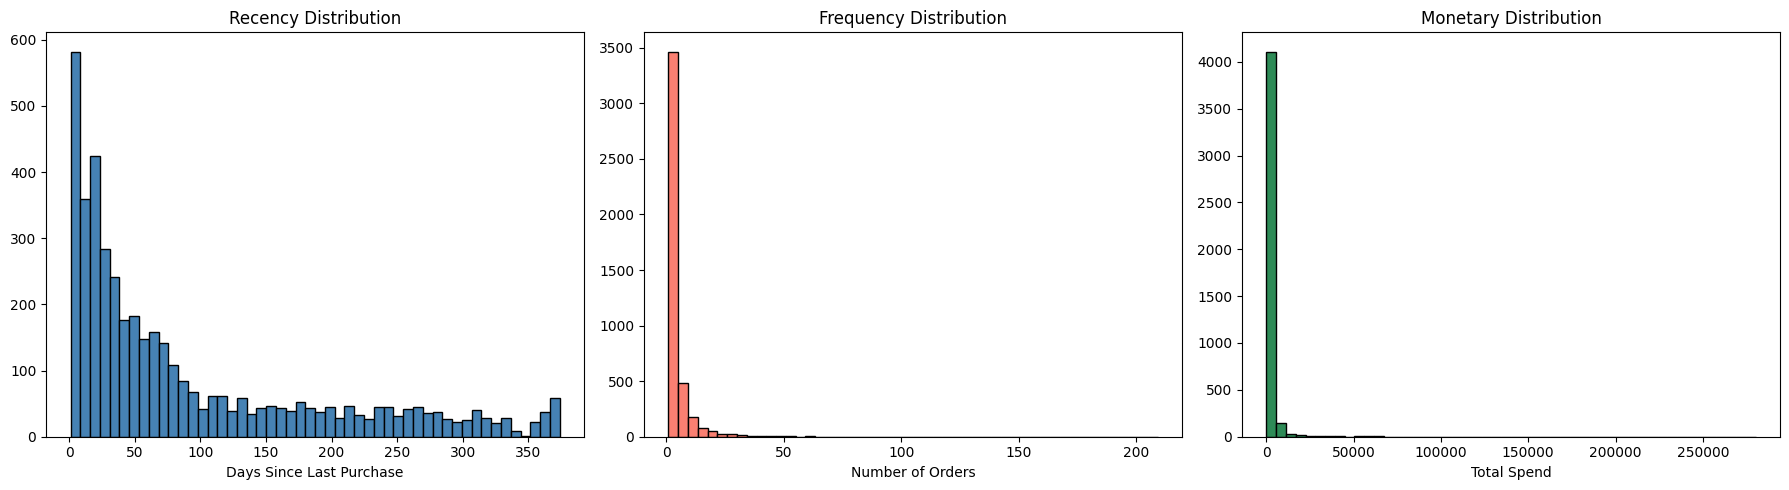

In [ ]:
# ---- STEP 2: Distribution Plots ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm['Recency'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')

axes[1].hist(rfm['Frequency'], bins=50, color='salmon', edgecolor='black')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Orders')

axes[2].hist(rfm['Monetary'], bins=50, color='seagreen', edgecolor='black')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spend')

plt.tight_layout()
plt.show()

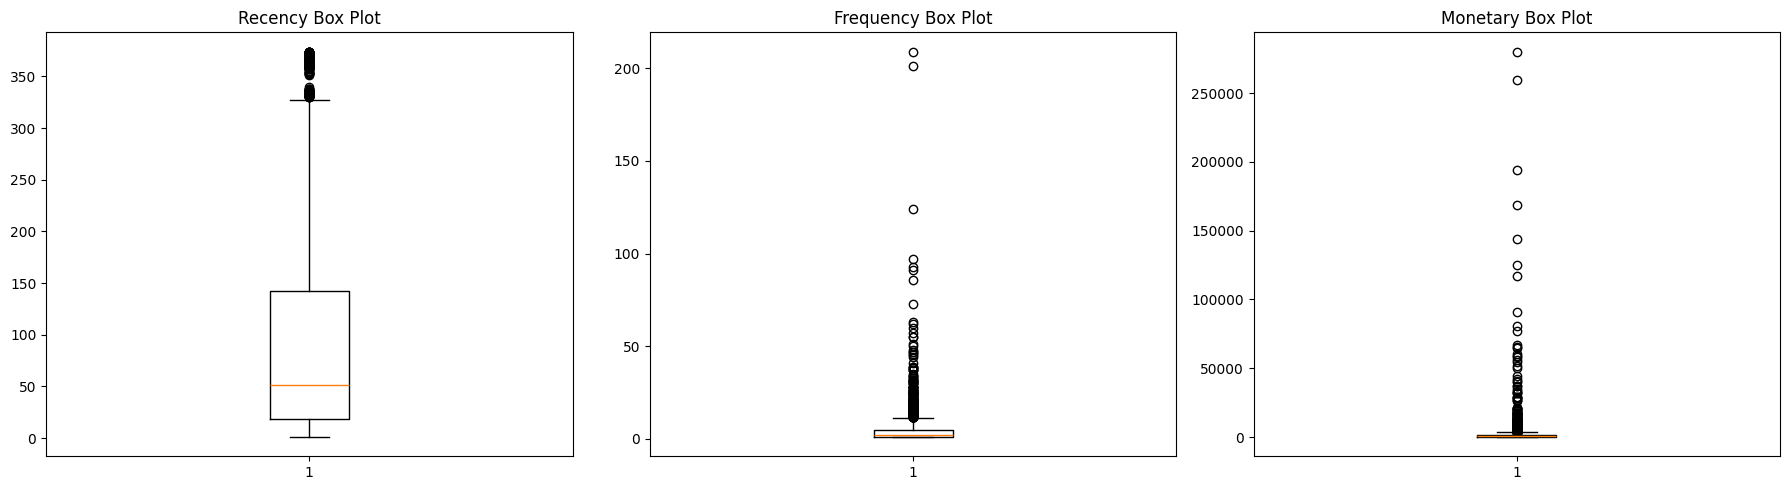

In [ ]:
# ---- STEP 3: Outlier Detection using Box Plots ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot(rfm['Recency'])
axes[0].set_title('Recency Box Plot')

axes[1].boxplot(rfm['Frequency'])
axes[1].set_title('Frequency Box Plot')

axes[2].boxplot(rfm['Monetary'])
axes[2].set_title('Monetary Box Plot')

plt.tight_layout()
plt.show()

In [ ]:
# ---- STEP 4: Identify Outliers with IQR ----
for col in ['Recency', 'Frequency', 'Monetary']:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = rfm[(rfm[col] < lower) | (rfm[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")

Recency: 155 outliers (Lower: -168.00, Upper: 328.00)
Frequency: 285 outliers (Lower: -5.00, Upper: 11.00)
Monetary: 425 outliers (Lower: -1724.69, Upper: 3691.77)


In [ ]:
# ---- STEP 5: Cap Outliers (instead of removing) ----
for col in ['Frequency', 'Monetary']:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    rfm[col] = rfm[col].clip(upper=upper)

print("After capping:")
rfm.describe()

After capping:


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.00000,4338.000000
mean,15300.408022,92.536422,3.48663,1159.010762
std,1721.808492,100.014169,3.04011,1146.777473
min,12346.000000,1.000000,1.00000,3.750000
25%,13813.250000,18.000000,1.00000,306.482500
50%,15299.500000,51.000000,2.00000,668.570000
75%,16778.750000,142.000000,5.00000,1660.597500
max,18287.000000,374.000000,11.00000,3691.770000


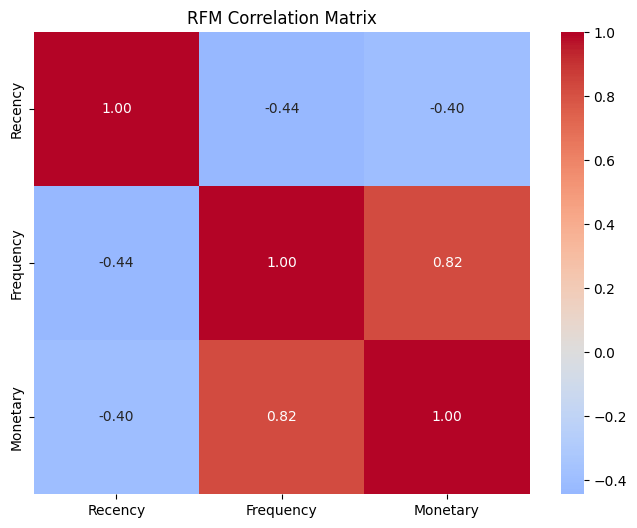

In [ ]:
# ---- STEP 6: Correlation Analysis ----
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('RFM Correlation Matrix')
plt.show()

                Customers  TotalRevenue  AvgOrderValue
Country                                               
United Kingdom       3920   7285024.644      20.861862
Netherlands             9    285446.340     121.003111
EIRE                    3    265262.460      36.709446
Germany                94    228678.400      25.338327
France                 87    208934.310      25.094200
Australia               9    138453.810     117.234386
Spain                  30     61558.560      24.832013
Switzerland            21     56443.950      30.659397
Belgium                25     41196.340      20.283772
Sweden                  8     38367.830      85.261844


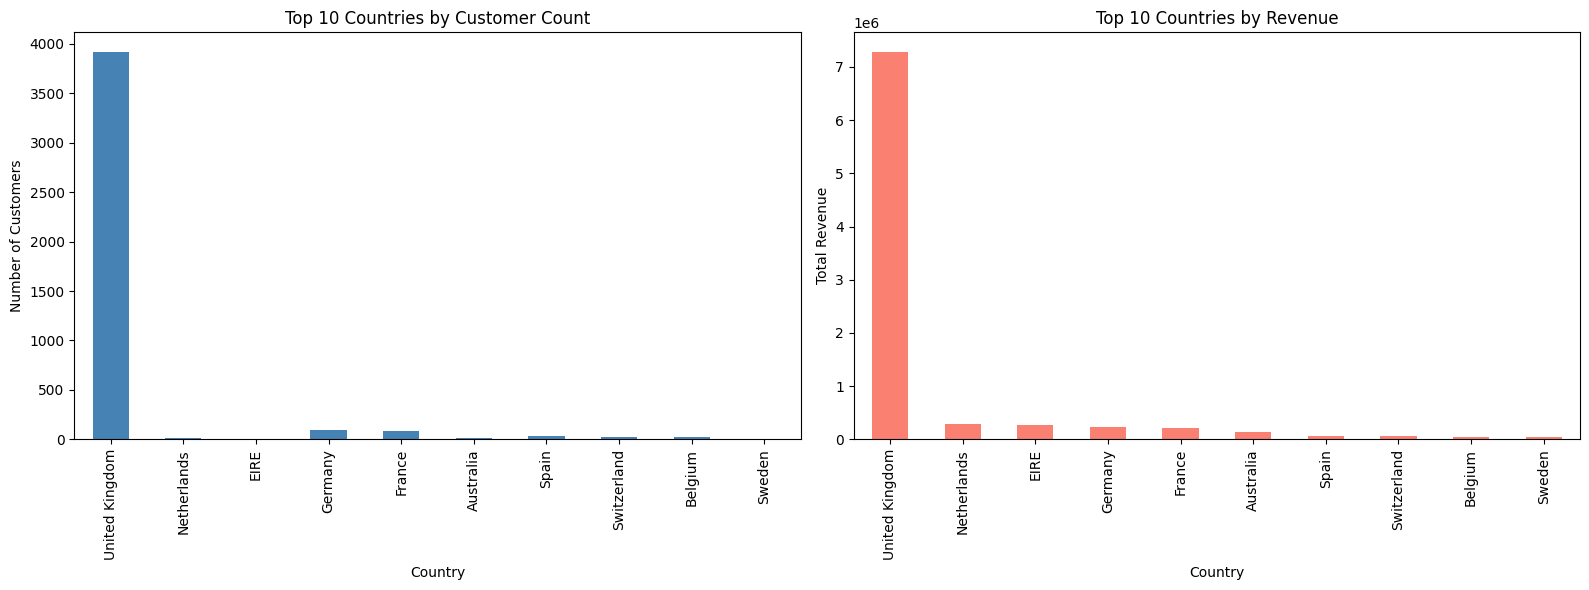

In [ ]:
# ---- STEP 7: Top Countries by Customer Count and Spend ----
country_stats = df.groupby('Country').agg(
    Customers=('CustomerID', 'nunique'),
    TotalRevenue=('TotalPrice', 'sum'),
    AvgOrderValue=('TotalPrice', 'mean')
).sort_values('TotalRevenue', ascending=False).head(10)

print(country_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

country_stats['Customers'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Countries by Customer Count')
axes[0].set_ylabel('Number of Customers')

country_stats['TotalRevenue'].plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Top 10 Countries by Revenue')
axes[1].set_ylabel('Total Revenue')

plt.tight_layout()
plt.show()

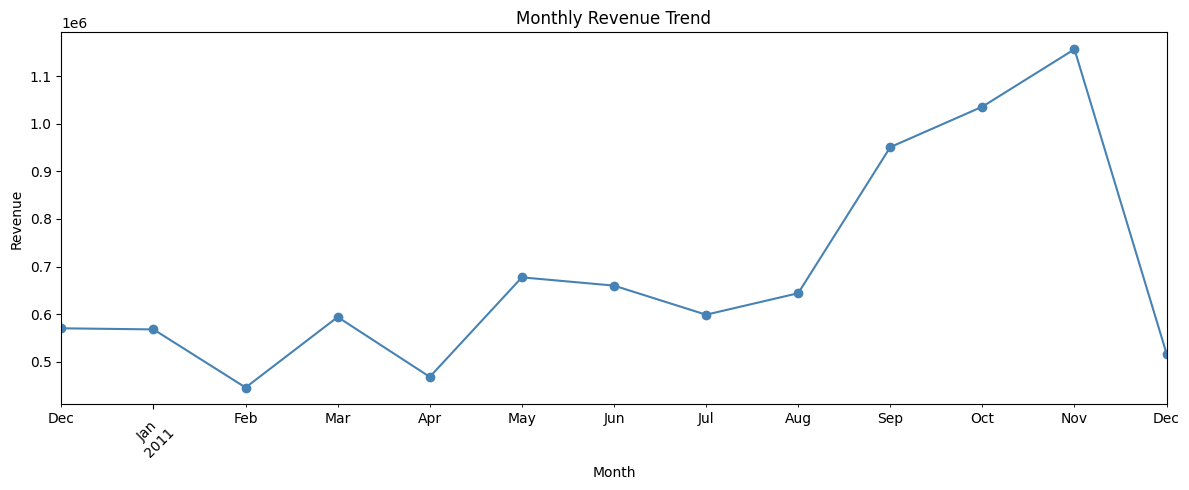

In [ ]:
# ---- STEP 8: Spending Patterns Over Time ----
monthly_revenue = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ---- STEP 1: Standardize the RFM Features ----
from sklearn.preprocessing import StandardScaler

rfm_scaled = rfm[['Recency', 'Frequency', 'Monetary']].copy()
scaler = StandardScaler()
rfm_scaled = pd.DataFrame(scaler.fit_transform(rfm_scaled), columns=['Recency', 'Frequency', 'Monetary'])

print("Scaled RFM Stats:")
rfm_scaled.describe()

Scaled RFM Stats:


,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.637950e-18,-1.703468e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-8.180350e-01,-1.007514e+00
25%,-7.453445e-01,-8.180350e-01,-7.434978e-01
50%,-4.153533e-01,-4.890616e-01,-4.277179e-01
75%,4.946227e-01,4.978585e-01,4.374385e-01
max,2.814561e+00,2.471699e+00,2.208843e+00


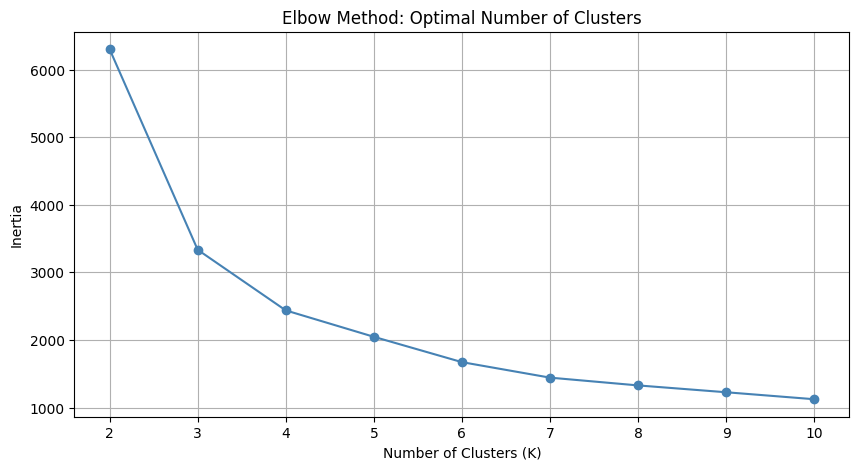

In [ ]:
# ---- STEP 2: Elbow Method to Find Optimal K ----
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method: Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

K=2: Silhouette Score = 0.5076
K=3: Silhouette Score = 0.5063
K=4: Silhouette Score = 0.4700
K=5: Silhouette Score = 0.4190
K=6: Silhouette Score = 0.4171
K=7: Silhouette Score = 0.4127
K=8: Silhouette Score = 0.3925
K=9: Silhouette Score = 0.3780
K=10: Silhouette Score = 0.3633


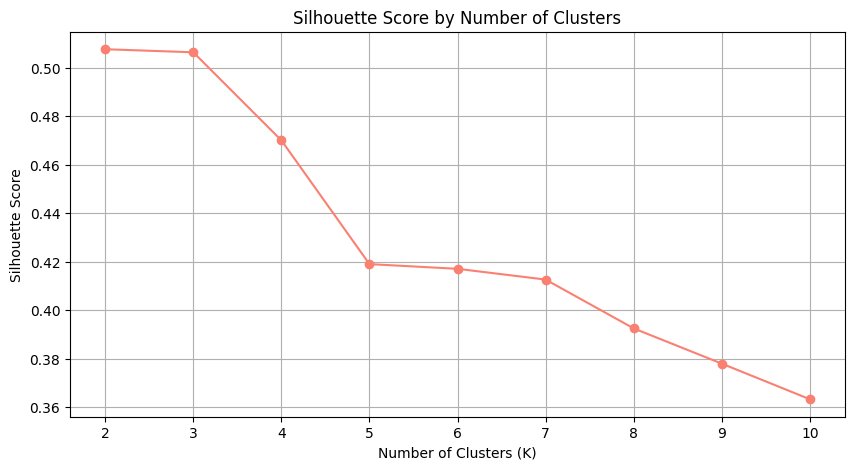

In [ ]:
# ---- STEP 3: Silhouette Score for Each K ----
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    sil_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(K_range, sil_scores, marker='o', color='salmon')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [ ]:
# ---- STEP 4: Apply K-Means with Optimal K ----
# Choose K based on elbow + silhouette (likely 3 or 4, pick the best from your plots)
optimal_k = 4  # adjust this based on your results

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Cluster Distribution:")
print(rfm['Cluster'].value_counts().sort_index())

Cluster Distribution:
Cluster
0     853
1    1928
2     988
3     569
Name: count, dtype: int64


In [ ]:
# ---- STEP 5: Profile Each Cluster ----
cluster_profile = rfm.groupby('Cluster').agg(
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean'),
    Count=('CustomerID', 'count')
).round(2)

print("Cluster Profiles:")
print(cluster_profile)

Cluster Profiles:
         Recency_Mean  Frequency_Mean  Monetary_Mean  Count
Cluster                                                    
0               39.83            5.00        1951.47    853
1               53.87            1.98         540.24   1928
2              255.05            1.44         407.09    988
3               20.40            9.86        3373.27    569


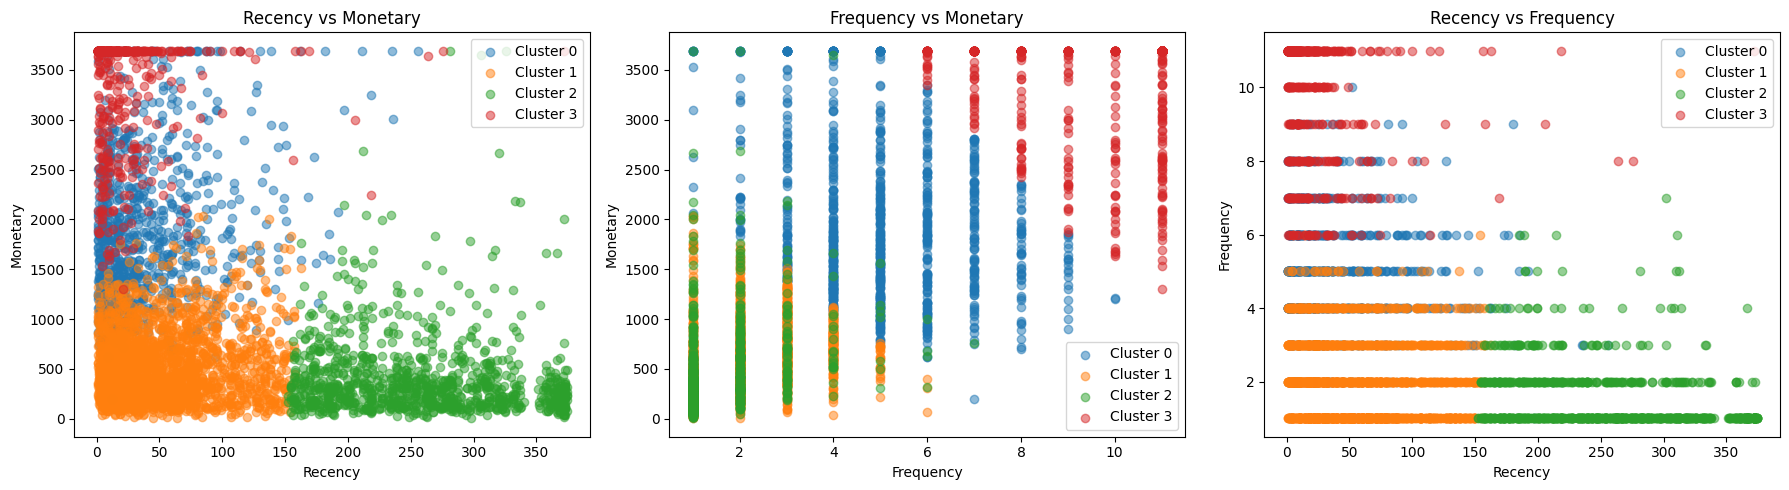

In [ ]:
# ---- STEP 6: Visualize Clusters ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cluster in range(optimal_k):
    subset = rfm[rfm['Cluster'] == cluster]
    axes[0].scatter(subset['Recency'], subset['Monetary'], label=f'Cluster {cluster}', alpha=0.5)
    axes[1].scatter(subset['Frequency'], subset['Monetary'], label=f'Cluster {cluster}', alpha=0.5)
    axes[2].scatter(subset['Recency'], subset['Frequency'], label=f'Cluster {cluster}', alpha=0.5)

axes[0].set_xlabel('Recency')
axes[0].set_ylabel('Monetary')
axes[0].set_title('Recency vs Monetary')
axes[0].legend()

axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary')
axes[1].set_title('Frequency vs Monetary')
axes[1].legend()

axes[2].set_xlabel('Recency')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Recency vs Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()

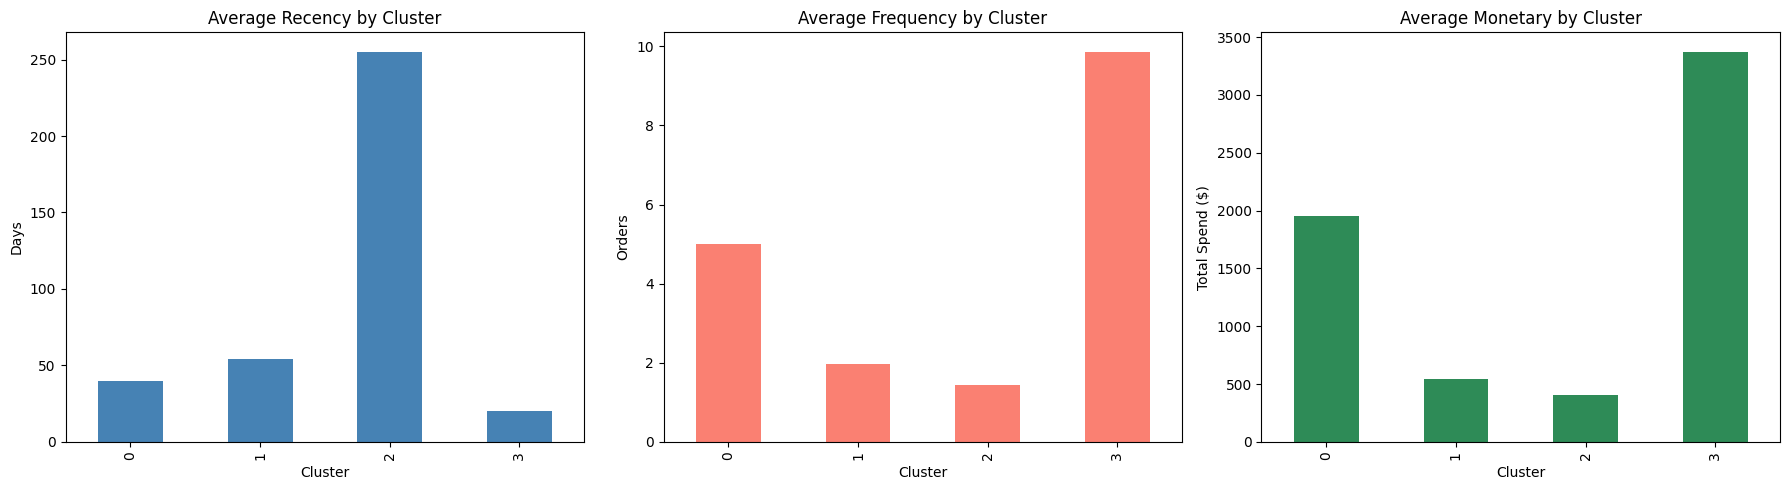

In [ ]:
# ---- STEP 7: Cluster Profile Bar Charts ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cluster_profile['Recency_Mean'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Recency by Cluster')
axes[0].set_ylabel('Days')

cluster_profile['Frequency_Mean'].plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Average Frequency by Cluster')
axes[1].set_ylabel('Orders')

cluster_profile['Monetary_Mean'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Average Monetary by Cluster')
axes[2].set_ylabel('Total Spend ($)')

plt.tight_layout()
plt.show()

In [ ]:
# ---- STEP 8: DBSCAN as Alternative ----
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=10)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

print("DBSCAN Cluster Distribution:")
print(rfm['DBSCAN_Cluster'].value_counts().sort_index())
print(f"\nNoise points (label = -1): {(rfm['DBSCAN_Cluster'] == -1).sum()}")

DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1      11
 0    4327
Name: count, dtype: int64

Noise points (label = -1): 11
